# Notebook 04 — Closed-Loop Adaptive Augmentation Pipeline

This notebook runs the **core adaptive loop** of the toolkit:

1. Loads all artefacts from Notebooks 01–03
2. Calls `loop_engine.execute_adaptive_loop()` which iteratively:
   - Generates targeted synthetic data from the fitted generator
   - Interleaves synthetic + real data
   - Retrains the classifier on the augmented dataset
   - Evaluates on the held-out test set
   - Applies **early stopping** when AUC improvement plateaus
3. Saves the final optimised model and a full training log (`training_loop_log.csv`)
4. Plots the performance trajectory across iterations

In [1]:
import sys, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from models_utils import load_model, evaluate_performance, save_model
from generator_utils import load_generator
from loop_engine import execute_adaptive_loop, save_metrics_log

%matplotlib inline
print('Imports OK')

Imports OK


## 1. Load All Artefacts

In [2]:
# ── Raw data splits (un-scaled) ──────────────────────────────────────────────
X_train = pd.read_csv('artifacts/X_train_clean.csv')
X_test  = pd.read_csv('artifacts/X_test_clean.csv')
y_train = pd.read_csv('artifacts/y_train_clean.csv').squeeze()
y_test  = pd.read_csv('artifacts/y_test_clean.csv').squeeze()

# ── Preprocessor ─────────────────────────────────────────────────────────────
preprocessor  = joblib.load('artifacts/preprocessor.pkl')
X_train_proc  = preprocessor.transform(X_train)
X_test_proc   = preprocessor.transform(X_test)

# ── Baseline model ───────────────────────────────────────────────────────────
baseline_model = load_model('artifacts/baseline_rf_model.pkl')

# ── Generator ────────────────────────────────────────────────────────────────
generator = load_generator('artifacts/sdv_copula_model.pkl')

# ── Target cohorts ────────────────────────────────────────────────────────────
with open('artifacts/target_cohorts.json') as f:
    target_cohorts = json.load(f)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Target cohorts   : {len(target_cohorts)}')
print(f'Baseline model   : {type(baseline_model).__name__}')

[model_utils] Model loaded <- artifacts/baseline_rf_model.pkl


[generator_utils] Synthesizer loaded <- artifacts/sdv_copula_model.pkl
Training samples : 3200
Test samples     : 800
Target cohorts   : 19
Baseline model   : RandomForestClassifier


## 2. Configure and Run the Adaptive Loop

In [3]:
# ── Loop hyperparameters ─────────────────────────────────────────────────────
LOOP_CONFIG = {
    'max_iterations':    7,      # Maximum augment-retrain cycles
    'n_samples_per_iter': 60,    # Synthetic samples requested per cohort per iteration
    'early_stop_threshold': 0.001,  # Minimum AUC gain to keep iterating
    'model_type': 'random_forest',
    'random_state': 42,
}

print('Loop configuration:')
for k, v in LOOP_CONFIG.items():
    print(f'  {k:25s}: {v}')

Loop configuration:
  max_iterations           : 7
  n_samples_per_iter       : 60
  early_stop_threshold     : 0.001
  model_type               : random_forest
  random_state             : 42


In [4]:
final_model, metrics_history = execute_adaptive_loop(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    X_train_proc=X_train_proc,
    X_test_proc=X_test_proc,
    preprocessor=preprocessor,
    initial_model=baseline_model,
    generator=generator,
    cohorts_metadata=target_cohorts,
    target_col='is_fraud',
    **LOOP_CONFIG
)


────────────────────────────────────────────────────────────
  Baseline  |  AUC=0.8950  F1=0.3396  Recall=0.2045
────────────────────────────────────────────────────────────

[loop_engine] ── Iteration 1/7 ──
[generator_utils] Cohort 'feature_1_band=(-1.115, -0.0944]': 3200 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_3_band=(1.696, 5.578]': 3200 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_3_band=(0.948, 1.696]': 3200 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_3_band=(-0.0212, 0.948]': 3200 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_4_band=(-3.733, -0.645]': 3200 real → generating 60 synthetic samples.


...

[generator_utils] Cohort 'feature_3_band=(-3.1399999999999997, -0.0212]': 10040 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_2_band=(0.0423, 0.725]': 10040 real → generating 60 synthetic samples.


[generator_utils] Cohort 'feature_4_band=(0.0171, 0.654]': 10040 real → generating 60 synthetic samples.


[generator_utils] Total synthetic samples generated: 1140


[model_utils] 'random_forest' trained on 11180 samples.
  Iter  7   |  AUC=0.8283  F1=0.3188  Recall=0.2500  ΔAUC=+0.0048  (+1140 synthetic)

────────────────────────────────────────────────────────────
[loop_engine] Loop complete. Best AUC: 0.8950
────────────────────────────────────────────────────────────



## 3. Performance Trajectory

In [5]:
log_df = pd.DataFrame(metrics_history)
print(log_df[['label', 'roc_auc', 'f1', 'recall', 'precision']].to_string(index=False))

   label  roc_auc       f1   recall  precision
baseline 0.894992 0.339623 0.204545   1.000000
  iter_1 0.867529 0.366667 0.250000   0.687500
  iter_2 0.877195 0.350877 0.227273   0.769231
  iter_3 0.861291 0.343750 0.250000   0.550000
  iter_4 0.867785 0.338462 0.250000   0.523810
  iter_5 0.856872 0.363636 0.272727   0.545455
  iter_6 0.823413 0.338462 0.250000   0.523810
  iter_7 0.828253 0.318841 0.250000   0.440000


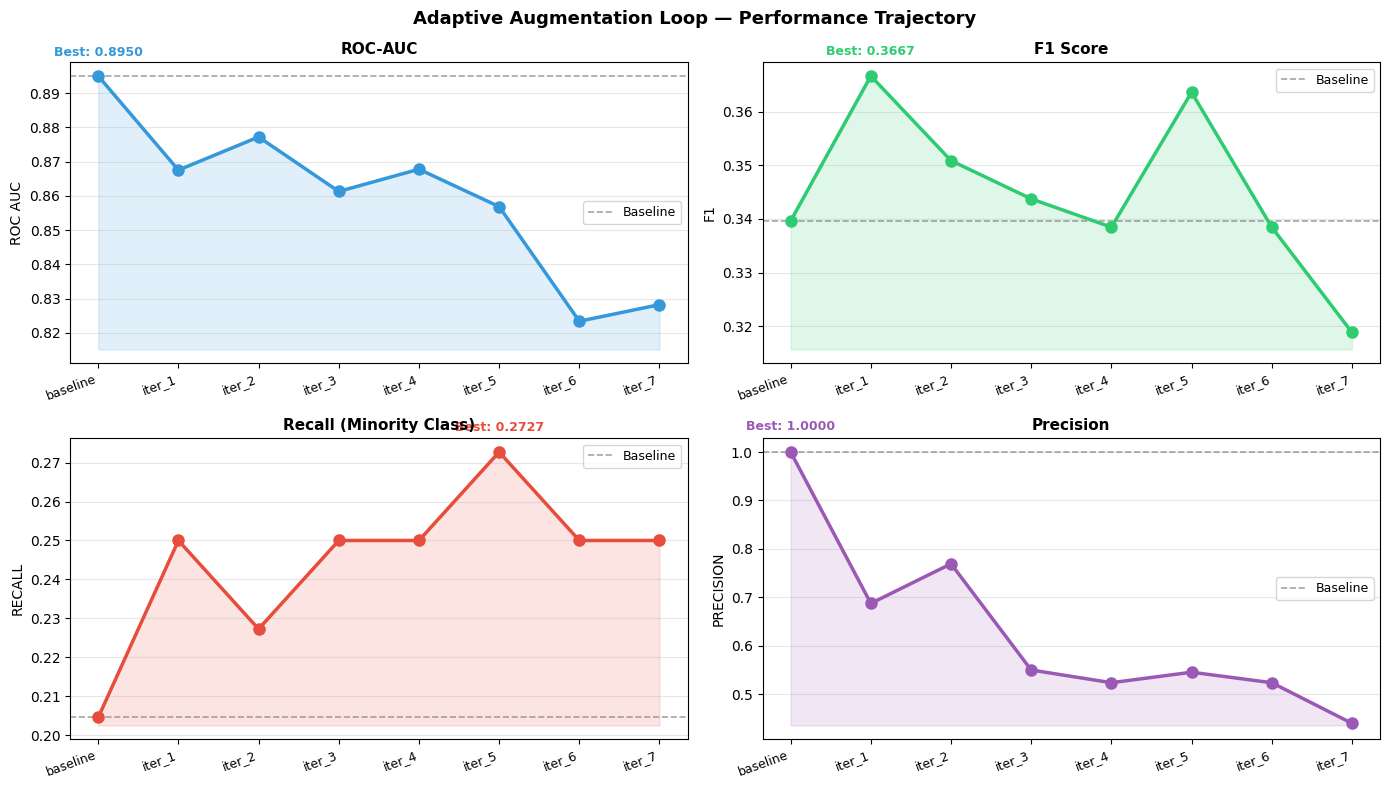

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics_to_plot = ['roc_auc', 'f1', 'recall', 'precision']
titles          = ['ROC-AUC', 'F1 Score', 'Recall (Minority Class)', 'Precision']
colors          = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, metric, title, color in zip(axes.flatten(), metrics_to_plot, titles, colors):
    values  = log_df[metric].values
    x_ticks = range(len(values))
    x_labels = log_df['label'].values

    ax.plot(x_ticks, values, marker='o', color=color, linewidth=2.5, markersize=8, zorder=3)
    ax.fill_between(x_ticks, values, min(values)*0.99, alpha=0.15, color=color)
    ax.axhline(values[0], color='gray', linestyle='--', linewidth=1.2, label='Baseline', alpha=0.7)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric.replace('_', ' ').upper())
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Annotate best value
    best_idx = np.argmax(values)
    ax.annotate(f'Best: {values[best_idx]:.4f}',
                xy=(best_idx, values[best_idx]),
                xytext=(best_idx, values[best_idx] + (max(values)-min(values))*0.08),
                ha='center', fontsize=9, color=color, fontweight='bold')

plt.suptitle('Adaptive Augmentation Loop — Performance Trajectory', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/loop_performance_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

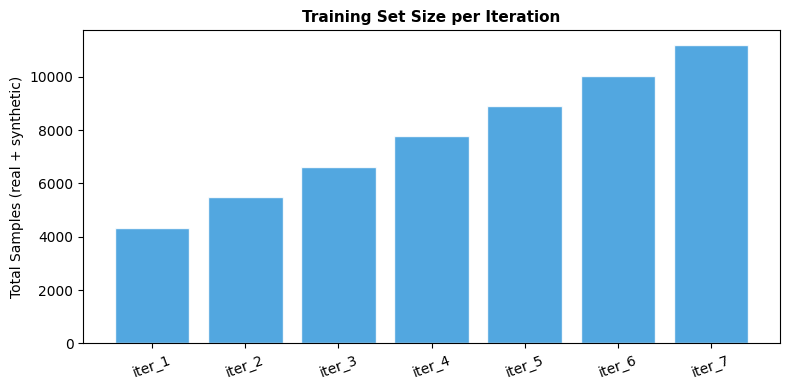

In [7]:
# --- Training set growth ---
if 'total_train_size' in log_df.columns:
    sizes = log_df.dropna(subset=['total_train_size'])
    plt.figure(figsize=(8, 4))
    plt.bar(sizes['label'], sizes['total_train_size'], color='#3498db', alpha=0.85, edgecolor='white')
    plt.title('Training Set Size per Iteration', fontsize=11, fontweight='bold')
    plt.ylabel('Total Samples (real + synthetic)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig('artifacts/loop_training_set_growth.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Final Model Evaluation vs. Baseline

In [8]:
print('=== Baseline Model ===')
baseline_metrics = evaluate_performance(baseline_model, X_test_proc, y_test.values, verbose=True)

print('=== Final Adapted Model ===')
final_metrics = evaluate_performance(final_model, X_test_proc, y_test.values, verbose=True)

print('\n=== Improvement Summary ===')
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    delta = final_metrics[metric] - baseline_metrics[metric]
    arrow = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'  {metric:12s}  baseline={baseline_metrics[metric]:.4f}  '
          f'final={final_metrics[metric]:.4f}  {arrow} {delta:+.4f}')

=== Baseline Model ===
[model_utils] Evaluation results:
  accuracy    : 0.9563
  precision   : 1.0000
  recall      : 0.2045
  f1          : 0.3396
  roc_auc     : 0.8950

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       756
           1       1.00      0.20      0.34        44

    accuracy                           0.96       800
   macro avg       0.98      0.60      0.66       800
weighted avg       0.96      0.96      0.94       800

=== Final Adapted Model ===
[model_utils] Evaluation results:
  accuracy    : 0.9563
  precision   : 1.0000
  recall      : 0.2045
  f1          : 0.3396
  roc_auc     : 0.8950

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       756
           1       1.00      0.20      0.34        44

    accuracy                           0.96       800
   macro avg       0.98      0.60      0.66       800
weighted avg       0.96      0.96      0.94       

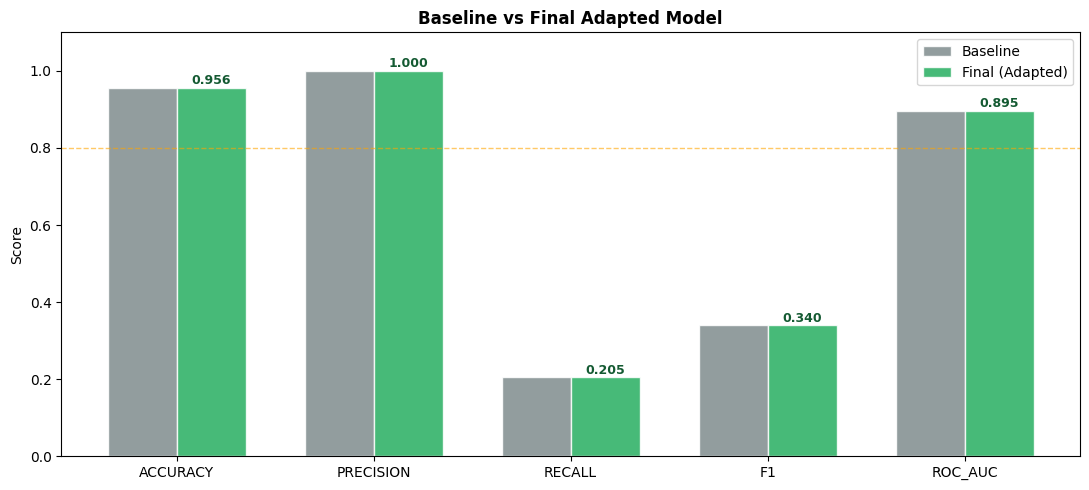

In [9]:
# Comparison bar chart
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, [baseline_metrics[k] for k in metrics_keys],
               width, label='Baseline', color='#7f8c8d', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, [final_metrics[k] for k in metrics_keys],
               width, label='Final (Adapted)', color='#27ae60', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_keys])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Baseline vs Final Adapted Model', fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(0.8, color='orange', linestyle='--', linewidth=1, alpha=0.6)

for bar, val in zip(bars2, [final_metrics[k] for k in metrics_keys]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', fontsize=9, color='#145a32', fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/loop_baseline_vs_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Final Artefacts

In [10]:
os.makedirs('artifacts', exist_ok=True)

# Save the best model
save_model(final_model, 'artifacts/final_adapted_model.pkl')

# Save the training loop log
save_metrics_log(metrics_history, path='artifacts/training_loop_log.csv')
print(log_df[['label','roc_auc','f1','recall']].to_string(index=False))

print('\n=== All artefacts saved ===')
for fname in os.listdir('artifacts'):
    fpath = os.path.join('artifacts', fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:40s}  ({size:,} bytes)')

[model_utils] Model saved -> artifacts/final_adapted_model.pkl
[loop_engine] Metrics log saved → artifacts/training_loop_log.csv
   label  roc_auc       f1   recall
baseline 0.894992 0.339623 0.204545
  iter_1 0.867529 0.366667 0.250000
  iter_2 0.877195 0.350877 0.227273
  iter_3 0.861291 0.343750 0.250000
  iter_4 0.867785 0.338462 0.250000
  iter_5 0.856872 0.363636 0.272727
  iter_6 0.823413 0.338462 0.250000
  iter_7 0.828253 0.318841 0.250000

=== All artefacts saved ===
  baseline_rf_model.pkl                     (241,257 bytes)
  error_analysis_cohort_recall.png          (155,143 bytes)
  error_analysis_overview.png               (48,462 bytes)
  final_adapted_model.pkl                   (241,353 bytes)
  loop_baseline_vs_final.png                (40,922 bytes)
  loop_performance_trajectory.png           (186,742 bytes)
  loop_training_set_growth.png              (30,045 bytes)
  preprocessor.pkl                          (2,861 bytes)
  sdv_copula_model.pkl                     